# 06 · cNMF result inspection

This read-only notebook reviews outputs from Notebook 05 or `scripts/run_cnmf_workflow.py`. It provides interactive views of K selection, program genes, sample-level usage, condition comparisons, grouped summaries, and spatial localization.

Match the result-selection controls to the completed run, then choose programs and cell groups to inspect.

In [1]:
import sys
from pathlib import Path

from IPython.display import display

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
SOURCE_ROOT = str(REPO_ROOT / "src")
if SOURCE_ROOT not in sys.path:
    sys.path.insert(0, SOURCE_ROOT)

from spatial_workflow.cnmf import (
    cnmf_status,
    join_usage_to_counts,
    load_cnmf_context,
    load_consensus_results,
    load_k_selection_stats,
    plot_k_selection,
    plot_sample_usage,
    plot_spatial_usage,
    plot_usage_heatmap,
    sample_usage_summary,
    summarize_usage,
    subset_usage_by_cell_type,
    top_genes_long,
    usage_columns,
)

CONFIG_PATH = REPO_ROOT / "configs" / "local.yaml"

from spatial_workflow.cnmf_usage_analysis import (
    select_usage_condition_result,
    test_usage_condition_changes,
)
from spatial_workflow.cnmf_usage_plotting import plot_usage_condition_violin

## Select a completed result

Specify the analysis name, lineage, annotation column, selected K, and review cell types used by the completed cNMF run. `REVIEW_CELL_TYPES=None` includes every non-missing label in the selected review column.

In [2]:
LINEAGE = "oligodendrocyte"
ANALYSIS_NAME = None

CELL_TYPE_KEY = "cluster_sub"
USAGE_CELL_TYPE_KEY = "cluster_sub"

REVIEW_CELL_TYPES = None
CELL_TYPES = None

COMPARTMENTS = "all"
CONDITIONS = "all"
SELECTED_K = None
config, spec, paths = load_cnmf_context(
    CONFIG_PATH,
    LINEAGE,
    cell_type_key=CELL_TYPE_KEY,
    analysis_name=ANALYSIS_NAME,
    cell_types=CELL_TYPES,
    compartments=COMPARTMENTS,
    conditions=CONDITIONS,
    selected_k=SELECTED_K,
)
status = cnmf_status(spec, paths)
display(status)
if not bool(status.set_index("stage").loc["consensus", "complete"]):
    raise FileNotFoundError(
        "Selected-K consensus is incomplete; finish Notebook 05 first."
    )

,stage,complete,observed,expected,artifact
0,input_export,True,5,5,/stor/scratch/WCAAR/rhyan_scratch/spatial-work...
1,sweep_prepare,True,2,2,/stor/scratch/WCAAR/rhyan_scratch/spatial-work...
2,sweep_factorize,True,315,315,/stor/scratch/WCAAR/rhyan_scratch/spatial-work...
3,sweep_combine,True,21,21,/stor/scratch/WCAAR/rhyan_scratch/spatial-work...
4,k_selection,True,2,2,/stor/scratch/WCAAR/rhyan_scratch/spatial-work...
5,selected_prepare,True,2,2,/stor/scratch/WCAAR/rhyan_scratch/spatial-work...
6,selected_factorize,True,100,100,/stor/scratch/WCAAR/rhyan_scratch/spatial-work...
7,selected_combine,True,1,1,/stor/scratch/WCAAR/rhyan_scratch/spatial-work...
8,consensus,True,6,6,/stor/scratch/WCAAR/rhyan_scratch/spatial-work...
9,usage_h5ad,True,1,1,/stor/scratch/WCAAR/rhyan_scratch/spatial-work...


## K-selection evidence

Compare stability and reconstruction error across candidate K values. Use this evidence together with program interpretability when choosing the selected fit.

In [50]:
k_stats = load_k_selection_stats(paths)
display(k_stats)
plot_k_selection(k_stats, selected_k=spec.selected_k).show()

,k,local_density_threshold,silhouette,prediction_error
0,10.0,0.5,0.818790,2.955008e+08
1,11.0,0.5,0.857006,2.943688e+08
2,12.0,0.5,0.795277,2.939274e+08
3,13.0,0.5,0.842204,2.928222e+08
4,14.0,0.5,0.801975,2.920080e+08
5,15.0,0.5,0.814675,2.912729e+08
6,16.0,0.5,0.830911,2.907999e+08
7,17.0,0.5,0.847326,2.902138e+08
8,18.0,0.5,0.814209,2.899946e+08
9,19.0,0.5,0.852869,2.887418e+08


## Consensus programs and top genes

Load the selected-K usage matrix and gene spectra, then inspect the highest-ranked genes for each program. Choose a subset of programs to simplify later plots.

In [3]:
usage, gene_scores, gene_tpm, top_genes = load_consensus_results(paths, spec)
adata = join_usage_to_counts(paths.counts_h5ad, usage)
programs = usage_columns(adata)

resolved_usage_cell_type_key = (
    config["cnmf"]["cell_type_key"]
    if USAGE_CELL_TYPE_KEY is None
    else str(USAGE_CELL_TYPE_KEY)
)
usage_obs = subset_usage_by_cell_type(
    adata.obs,
    cell_type_key=resolved_usage_cell_type_key,
    cell_types=REVIEW_CELL_TYPES,
)
included_usage_cell_types = usage_obs.attrs["cell_types"]

result_summary = {
    "analysis": spec.name,
    "cells": adata.n_obs,
    "genes": adata.n_vars,
    "programs": len(programs),
    "usage cell-type key": resolved_usage_cell_type_key,
    "usage-review cells": len(usage_obs),
    "usage-review cell types": included_usage_cell_types,
    "selected K": spec.selected_k,
    "density threshold": spec.density_threshold,
}
display(result_summary)

{'analysis': 'oligodendrocyte',
 'cells': 189654,
 'genes': 5006,
 'programs': 25,
 'usage cell-type key': 'cluster_sub',
 'usage-review cells': 189654,
 'usage-review cell types': ['OLIG_sub1',
  'OLIG_sub3',
  'OLIG_sub0',
  'OLIG_sub5',
  'OLIG_sub8',
  'OPC',
  'OLIG_sub4',
  'OLIG_sub12',
  'OLIG_sub2',
  'OLIG_sub7',
  'OLIG_sub14',
  'OLIG_sub10',
  'OLIG_sub11',
  'OLIG_sub6',
  'OLIG_sub9',
  'OLIG_sub13'],
 'selected K': 25,
 'density threshold': 0.1}

In [4]:
for column in top_genes.columns:
    print(f"Top genes for {column}:")
    print(top_genes[column].to_list())

Top genes for Usage_1:
['Sept4', 'Mag', 'Cryab', 'Efnb3', 'Opalin', 'Cnp', 'Il33', 'Edil3', 'Lgi3', 'Bin1', 'Cntn2', 'Gabrr2', 'Ppp1r16b', 'App', 'Mcam', 'Neat1', 'Kndc1', 'Nkain1', 'Sez6l2', 'Rnf13', 'Myrf', 'Mapt', 'Cd81', 'Map7', 'Mast3', 'Smtn', 'Ccp110', 'Gprc5b', 'Nkx6-2', 'Zfp536', 'Rhoa', 'Daam2', 'Bcar1', 'Bcl2l1', 'Kif1b', 'Aplp2', 'Gna12', 'Mapk8ip1', 'Erbin', 'S1pr5', 'Sema6d', 'Mog', 'Ddr1', 'Gstp1', 'Ddit4', 'Epb41l3', 'Olig1', 'Adamts1', 'Ywhae', 'Jup', 'Plekha1', 'Tyro3', 'Sox10', 'Myo18a', 'Rnf130', 'Ncam1', 'Kdm4a', 'Arrdc3', 'Sv2a', 'Il1rap', 'Erbb3', 'Srebf1', 'Zbtb16', 'Abca8a', 'Sqstm1', 'Fgfr2', 'Gab1', 'Lamp1', 'Smad7', 'Fryl', 'Cd9', 'Pde8a', 'Slc6a8', 'Agpat4', 'Pls1', 'Dusp7', 'Kit', 'Ckb', 'Gnai2', 'Sh3bp2', 'Gnao1', 'Ankrd13a', 'Foxj1', 'Slc12a2', 'Cers2', 'Wrap53', 'Hadh', 'Elmo1', 'Cd82', 'Rtn4', 'Slc6a9', 'Nr1h2', 'Hspa1b', 'Fam83d', 'Dctn1', 'Grm3', 'Snx30', 'Cdk5', 'Rab7', 'Mcl1']
Top genes for Usage_2:
['Rhog', 'Dst', 'Psat1', 'Ccp110', 'Dpysl2', 'Mog

## Usage by biological sample

The plots summarize program usage using one mean per biological sample. Review filters are applied before sample means are calculated, so cells are not treated as independent replicates.

In [53]:
# mask = usage_obs['cluster_sub']=='OLIG_sub7'
SELECTED_PROGRAMS = programs[9:]
SELECTED_PROGRAMS = [programs[0], programs[8], programs[13], programs[14], programs[17]]
sample_summary = sample_usage_summary(
    usage_obs,
    # usage_obs[mask],
    sample_key=config["cnmf"]["sample_key"],
    condition_key=config["cnmf"]["condition_key"],
    usage_cols=SELECTED_PROGRAMS,
)
display(sample_summary)
plot_sample_usage(
    sample_summary,
    condition_key=config["cnmf"]["condition_key"],
    sample_key=config["cnmf"]["sample_key"],
    programs=SELECTED_PROGRAMS,
).show()



,condition,sample_id,program,mean_usage,median_usage,n_cells
0,naive_igg,naive_70_igg,Usage_1,0.164084,0.029918,14208
1,naive_igg,naive_72_igg,Usage_1,0.239174,0.039464,12299
2,naive_igg,naive_75_igg,Usage_1,0.197267,0.030826,13759
3,naive_igg,naive_77_igg,Usage_1,0.142060,0.024507,14547
4,vap_ab,vap_38_ab,Usage_1,0.171396,0.025694,13193
5,vap_ab,vap_41_ab,Usage_1,0.219512,0.033132,13460
6,vap_ab,vap_49_ab,Usage_1,0.130341,0.028504,12660
7,vap_ab,vap_52_ab,Usage_1,0.127747,0.021324,14328
8,vap_igg,vap_42_igg,Usage_1,0.169311,0.027546,12367
9,vap_igg,vap_46_igg,Usage_1,0.113041,0.022438,13045


## Condition-associated usage

This section tests condition differences using biological-sample means. It reports effect sizes, Welch tests, exact or enumerated permutation tests, and multiple-testing corrections.

Use the interactive plot to inspect the cell-level distribution behind a selected sample-level result; the cells themselves are not used as statistical replicates.

In [54]:
# Each tuple is (condition A, condition B); delta = A - B.
USAGE_CONDITION_CONTRASTS = [
    ("vap_ab", "vap_igg"),
    ("vap_igg", "naive_igg"),
    ("vap_ab", "naive_igg"),
]
MIN_USAGE_CELLS_PER_SAMPLE = 10
MIN_USAGE_SAMPLES_PER_CONDITION = 3

# None selects the best corrected result for PLOT_USAGE_CONTRAST.
PLOT_USAGE_CONTRAST = ("vap_ab", "vap_igg")
PLOT_USAGE_CELL_TYPE = None
PLOT_USAGE_PROGRAM = None
PLOT_USAGE_SORT_BY = "welch_q_global"

USAGE_CONDITION_ORDER = ["naive_igg", "vap_igg", "vap_ab"]
USAGE_CONDITION_LABELS = {
    "naive_igg": "no vapor IgG",
    "vap_igg": "vapor IgG",
    "vap_ab": "vapor Ab",
}
USAGE_CONDITION_PALETTE = {
    "naive_igg": "#4C1D57",
    "vap_igg": "#F3B37A",
    "vap_ab": "#2A9D8F",
}

In [55]:
usage_condition_tests = test_usage_condition_changes(
    usage_obs,
    cell_type_key=resolved_usage_cell_type_key,
    sample_key=config["cnmf"]["sample_key"],
    condition_key=config["cnmf"]["condition_key"],
    contrasts=USAGE_CONDITION_CONTRASTS,
    usage_cols=programs,
    min_cells_per_sample=MIN_USAGE_CELLS_PER_SAMPLE,
    min_samples_per_condition=MIN_USAGE_SAMPLES_PER_CONDITION,
)

condition_test_display_columns = [
    resolved_usage_cell_type_key,
    "program",
    "contrast",
    "delta_a_minus_b",
    "mean_usage_a",
    "mean_usage_b",
    "n_samples_a",
    "n_samples_b",
    "min_n_cells_a",
    "min_n_cells_b",
    "welch_p",
    "welch_q_within_contrast",
    "welch_q_global",
    "permutation_p",
    "permutation_q_within_contrast",
    "permutation_q_global",
]
display(usage_condition_tests[condition_test_display_columns].head(50))

,cluster_sub,program,contrast,delta_a_minus_b,mean_usage_a,mean_usage_b,n_samples_a,n_samples_b,min_n_cells_a,min_n_cells_b,welch_p,welch_q_within_contrast,welch_q_global,permutation_p,permutation_q_within_contrast,permutation_q_global
0,MSN-D2,Usage_16,vap_ab_vs_naive_igg,0.018786,0.051032,0.032246,4,4,1024,1255,0.002685,0.187162,0.501664,0.028571,0.475000,0.670588
1,IN-SST-RTN,Usage_16,vap_ab_vs_naive_igg,0.003828,0.013869,0.010041,4,4,1740,1779,0.002814,0.187162,0.501664,0.028571,0.475000,0.670588
2,IN-SST-RTN,Usage_19,vap_igg_vs_naive_igg,0.001156,0.007686,0.006530,4,4,1686,1779,0.005546,0.278702,0.501664,0.028571,0.542857,0.670588
3,MSN-D1,Usage_14,vap_igg_vs_naive_igg,0.002784,0.021999,0.019215,4,4,1043,1498,0.005742,0.278702,0.501664,0.028571,0.542857,0.670588
4,IN-SST-RTN,Usage_16,vap_igg_vs_naive_igg,0.003855,0.013896,0.010041,4,4,1686,1779,0.006287,0.278702,0.501664,0.028571,0.542857,0.670588
5,IN-VIP-ARC,Usage_16,vap_igg_vs_naive_igg,0.011193,0.025837,0.014644,4,4,290,267,0.010309,0.342770,0.597387,0.028571,0.542857,0.670588
6,IN-VIP-ARC,Usage_10,vap_ab_vs_vap_igg,0.002168,0.010058,0.007890,4,4,335,290,0.010480,0.997179,0.597387,0.028571,1.000000,0.670588
7,IN-GABA-HT-AMY,Usage_16,vap_ab_vs_naive_igg,0.003911,0.012583,0.008672,4,4,5720,4907,0.013728,0.566439,0.666371,0.028571,0.475000,0.670588
8,IN-PV,Usage_16,vap_igg_vs_naive_igg,0.003056,0.010858,0.007802,4,4,1135,1169,0.015031,0.399823,0.666371,0.028571,0.542857,0.670588
9,IN-VIP-ARC,Usage_16,vap_ab_vs_naive_igg,0.008193,0.022837,0.014644,4,4,335,267,0.019234,0.566439,0.767455,0.028571,0.475000,0.670588


,value
cluster_sub,IN-VIP-ARC
program,Usage_10
condition_a,vap_ab
condition_b,vap_igg
contrast,vap_ab_vs_vap_igg
n_samples_a,4
n_samples_b,4
min_n_cells_a,335
min_n_cells_b,290
median_n_cells_a,559.5


,sample_id,condition_raw,condition_display,mean,median,n_cells
0,naive_70_igg,naive_igg,no vapor IgG,0.008380,0.0,386
1,naive_72_igg,naive_igg,no vapor IgG,0.005708,0.0,267
2,naive_75_igg,naive_igg,no vapor IgG,0.011278,0.0,787
3,naive_77_igg,naive_igg,no vapor IgG,0.010371,0.0,835
4,vap_42_igg,vap_igg,vapor IgG,0.008679,0.0,574
5,vap_46_igg,vap_igg,vapor IgG,0.007315,0.0,290
6,vap_50_igg,vap_igg,vapor IgG,0.007468,0.0,516
7,vap_51_igg,vap_igg,vapor IgG,0.008097,0.0,400
8,vap_38_ab,vap_ab,vapor Ab,0.010714,0.0,567
9,vap_41_ab,vap_ab,vapor Ab,0.010408,0.0,552


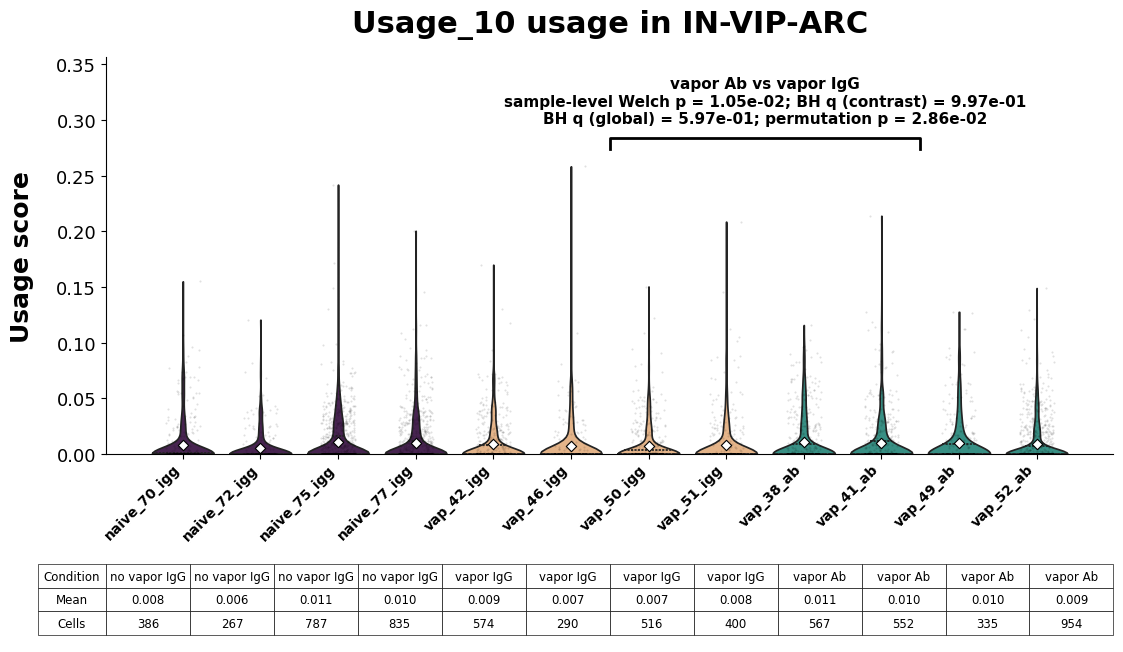

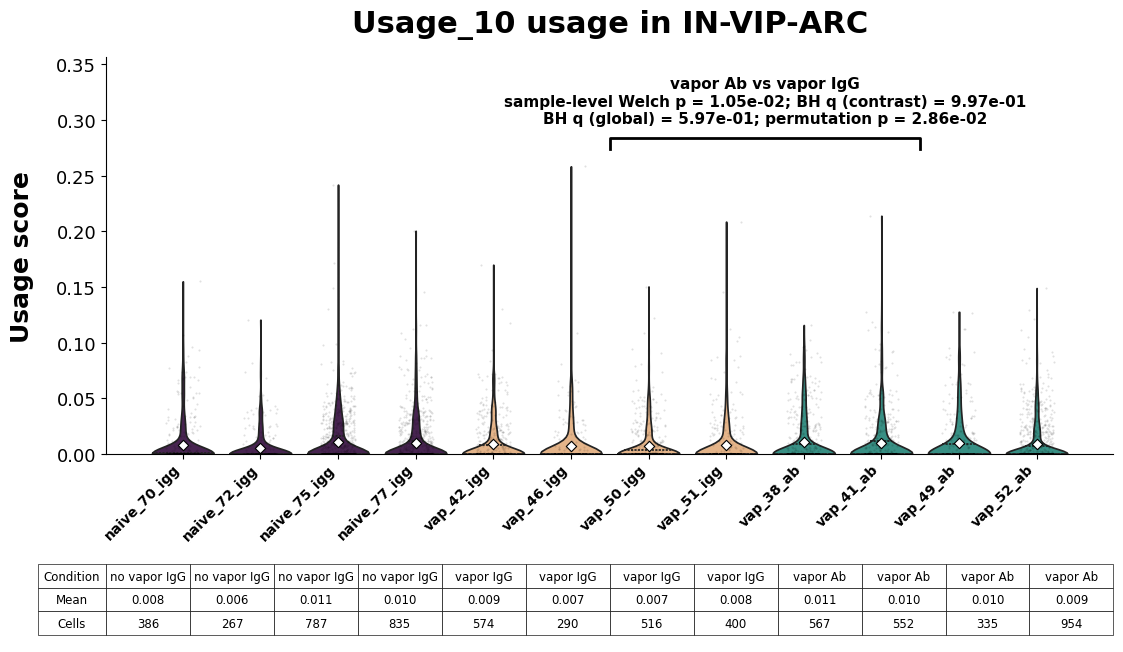

In [56]:
focus_usage_condition_result = select_usage_condition_result(
    usage_condition_tests,
    contrast=PLOT_USAGE_CONTRAST,
    cell_type_key=resolved_usage_cell_type_key,
    cell_type=PLOT_USAGE_CELL_TYPE,
    program=PLOT_USAGE_PROGRAM,
    sort_by=PLOT_USAGE_SORT_BY,
)
display(focus_usage_condition_result.to_frame("value"))

available_usage_conditions = set(usage_obs[config["cnmf"]["condition_key"]].astype(str))
shown_usage_condition_order = [
    condition
    for condition in USAGE_CONDITION_ORDER
    if condition in available_usage_conditions
]
focus_usage_figure, focus_usage_sample_summary = plot_usage_condition_violin(
    usage_obs,
    result=focus_usage_condition_result,
    cell_type_key=resolved_usage_cell_type_key,
    sample_key=config["cnmf"]["sample_key"],
    condition_key=config["cnmf"]["condition_key"],
    condition_order=shown_usage_condition_order,
    condition_labels=USAGE_CONDITION_LABELS,
    palette=USAGE_CONDITION_PALETTE,
)
display(focus_usage_sample_summary)
focus_usage_figure

## Grouped usage summaries

These descriptive tables and heatmaps compare mean program usage by condition, spatial domain, and the selected review annotation. They are intended for interpretation, not independent hypothesis tests.

In [57]:
for group_column in [
    config["cnmf"]["condition_key"],
    config["cnmf"]["compartment_key"],
    resolved_usage_cell_type_key,
]:
    grouped = summarize_usage(
        usage_obs,
        group_columns=[group_column],
        usage_cols=SELECTED_PROGRAMS,
    )
    display(grouped)
    plot_usage_heatmap(
        grouped,
        group_column=group_column,
        title=f"Mean usage by {group_column}",
    ).show()

,condition,program,mean_usage,median_usage,n_cells
0,naive_igg,Usage_1,0.183417,0.030573,54813
1,vap_ab,Usage_1,0.162121,0.026724,53641
2,vap_igg,Usage_1,0.183344,0.030000,54237
3,naive_igg,Usage_9,0.053655,0.016298,54813
4,vap_ab,Usage_9,0.049524,0.013943,53641
5,vap_igg,Usage_9,0.056452,0.016143,54237
6,naive_igg,Usage_14,0.019862,0.009487,54813
7,vap_ab,Usage_14,0.021609,0.010765,53641
8,vap_igg,Usage_14,0.021006,0.010189,54237
9,naive_igg,Usage_15,0.022775,0.013131,54813


/stor/scratch/WCAAR/rhyan_scratch/spatial-workflow/src/spatial_workflow/cnmf.py:1609: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  rows = (len(selected) + 3) // 4


,spatial_domain,program,mean_usage,median_usage,n_cells
0,0,Usage_1,0.026592,0.018588,8491
1,1,Usage_1,0.027194,0.014586,4580
2,10,Usage_1,0.618954,0.674203,40758
3,11,Usage_1,0.015648,0.002069,997
4,12,Usage_1,0.382802,0.435877,81
...,...,...,...,...,...
60,5,Usage_18,0.012840,0.001554,49278
61,6,Usage_18,0.025448,0.001641,1475
62,7,Usage_18,0.015686,0.002607,7460
63,8,Usage_18,0.014145,0.002112,19304


/stor/scratch/WCAAR/rhyan_scratch/spatial-workflow/src/spatial_workflow/cnmf.py:1609: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  rows = (len(selected) + 3) // 4


,cluster_sub,program,mean_usage,median_usage,n_cells
0,IN-ChAT,Usage_1,0.015108,0.000000,1760
1,IN-GABA-HT-AMY,Usage_1,0.028945,0.013042,77739
2,IN-PV,Usage_1,0.031663,0.023429,15066
3,IN-SST-RTN,Usage_1,0.025573,0.013305,22609
4,IN-VIP-ARC,Usage_1,0.021379,0.000000,6463
5,MSN-D1,Usage_1,0.620982,0.660208,21132
6,MSN-D2,Usage_1,0.675216,0.711760,17922
7,IN-ChAT,Usage_9,0.032976,0.000000,1760
8,IN-GABA-HT-AMY,Usage_9,0.060876,0.023539,77739
9,IN-PV,Usage_9,0.124296,0.050929,15066


## Spatial program map

Choose one biological sample and one program to display cell-level usage in tissue coordinates. Use the map to assess anatomical coherence and localized technical artifacts.

In [59]:
SELECTED_PROGRAMS

['Usage_1', 'Usage_9', 'Usage_14', 'Usage_15', 'Usage_18']

In [61]:
SAMPLE_KEY = config["cnmf"]["sample_key"]
SPATIAL_KEY = config["cnmf"]["spatial_key"]
SELECTED_SAMPLE = str(adata.obs[SAMPLE_KEY].astype(str).iloc[0])
SELECTED_SPATIAL_PROGRAM = SELECTED_PROGRAMS[0]
SELECTED_SPATIAL_PROGRAM = 'Usage_10'

plot_spatial_usage(
    adata,
    program=SELECTED_SPATIAL_PROGRAM,
    sample=SELECTED_SAMPLE,
    sample_key=SAMPLE_KEY,
    spatial_key=SPATIAL_KEY,
).show()